# Intent routing: data analysis, model comparison and recommendation

This notebook brings the relevant parts of the data analysis, logistic regression (LR), random forest (RF), and neural network (MLP) notebooks together.

Our question is simple: **can a classifier use a supplied embedding to decide whether a query should enter the nursing workflow?** We compare quality, missed queries, unnecessary referrals, and cost. A more complicated model is useful only if its results justify it.

All supporting code, supplied data, saved model outputs, and analysis tables used here are inside **`src/` beside this notebook**. The original LR/RF/MLP folders are not needed by this notebook. Existing results were produced in the earlier experiments; this combined notebook has been assembled without executing it.

**Setup:** install `src/requirements.txt` into your Python environment and select that environment as the notebook kernel. Run the cells from top to bottom. Leave `RETRAIN_ALL = False` to read the included results. Set it to `True` only to rerun all three training experiments; this can take substantial time and overwrites the bundled experiment outputs.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Works when opened from submission, its parent, or a directory below submission.
SUBMISSION = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / 'submission')
    if (candidate / 'src' / 'submission_tools.py').is_file()
)
sys.path.insert(0, str(SUBMISSION / 'src'))
import submission_tools as st

RETRAIN_ALL = False
pd.set_option('display.max_columns', 20)
print('Submission folder:', SUBMISSION)
print('All supporting files:', st.SRC)


Submission folder: c:\Aditya\Prep\noora\submission
All supporting files: C:\Aditya\Prep\noora\submission\src


## 1. What data do we have?

A row in the training CSV describes one query. Its **label** is the known routing answer: `relevant` or `irrelevant`. Its **intent** is a more detailed category, such as Medical or Greeting. We use intent to understand errors, not as an input feature.

An **embedding** is a list of numbers representing a query. A, B, and C are three alternative representations of the same rows, with 384, 768, and 1,536 coordinates respectively. A and B are described as local alternatives; C is hosted. The exact encoders are not provided.

The training set contains 903 labeled queries. The blind test contains 904 query IDs and their embeddings, but **no ground-truth labels or intents**. The supplied LLM files contain predictions, not additional truth labels. Raw query text is not supplied.

,Artifact,Count
0,Labeled development rows,903
1,Blind test rows,904
2,Relevant,557
3,Irrelevant,346


,Space,Rows,Dimensions
0,A,903,384
1,B,903,768
2,C,903,1536


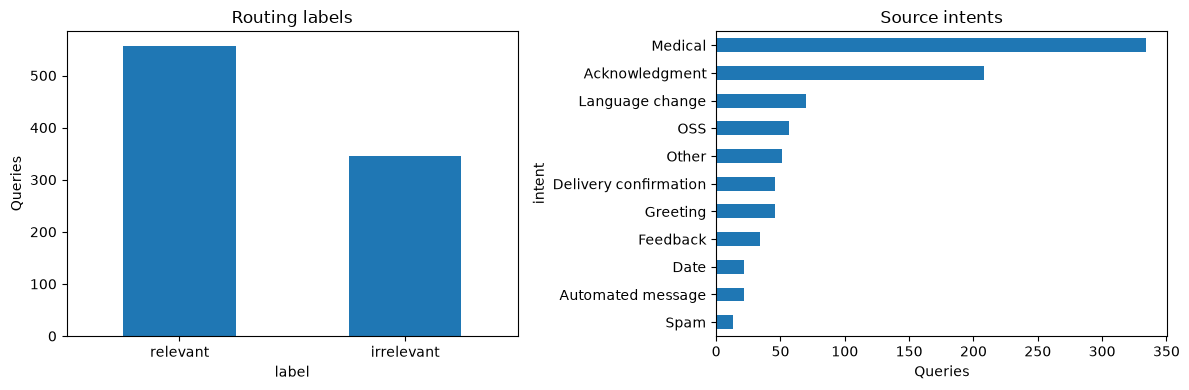

In [2]:
train, test, embeddings = st.training_data()
display(pd.DataFrame({
    'Artifact': ['Labeled development rows', 'Blind test rows', 'Relevant', 'Irrelevant'],
    'Count': [len(train), len(test), train.label.eq('relevant').sum(), train.label.eq('irrelevant').sum()]
}))
display(pd.DataFrame([{'Space': name, 'Rows': matrix.shape[0], 'Dimensions': matrix.shape[1]} for name, matrix in embeddings.items()]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train.label.value_counts().plot.bar(ax=axes[0], title='Routing labels', rot=0)
train.intent.value_counts().sort_values().plot.barh(ax=axes[1], title='Source intents')
axes[0].set_ylabel('Queries')
axes[1].set_xlabel('Queries')
plt.tight_layout()
plt.show()


## 2. How does a query ID connect the files?

`query_id` is a matching key, not an array position. The first CSV row corresponds to the first embedding row because that ordering is part of the supplied data contract. To find a query's embedding, first find its CSV row position. Join the LLM predictions by `query_id`.

The example below shows a training query, its known answer, an embedding preview, and the LLM prediction. For a test query the same matching approach works, but its true label remains unknown.

In [3]:
query_id = train.iloc[0].query_id  # Replace with another training ID to explore it.
row_position = int(np.flatnonzero(train.query_id.eq(query_id).to_numpy())[0])
llm_predictions = pd.read_json(st.DATA / 'llm_baseline_train_predictions.json')
display(train.iloc[[row_position]].merge(llm_predictions, on='query_id', how='left'))
print('CSV / embedding row position:', row_position)
print('First 8 coordinates in embedding A:', embeddings['A'][row_position, :8])


,query_id,intent,label,predicted_intent,predicted_label
0,q_01749,Delivery confirmation,relevant,Delivery confirmation,relevant


CSV / embedding row position: 0
First 8 coordinates in embedding A: [ 0.06900091  0.02938883  0.02048984  0.06948062 -0.00093758 -0.052225
  0.05227558  0.03056144]


## 3. Do the embedding spaces separate the labels naturally?

In this section, we compare three kinds of evidence. **PCA** compresses the vectors for a two-dimensional picture. **Silhouette** measures separation between labeled groups in the original space; values near zero suggest substantial overlap. **Neighbour agreement** asks how often nearby points have the same label.

The scatter plots show only a small fraction of the original variance. A clean-looking island does not prove that a classifier will generalize, and visual overlap does not prove that classification is impossible. PCA preserves variance, which is not necessarily the information needed for routing. The quantitative table below comes from the earlier data-analysis run.

,space,dimensions,binary_silhouette,intent_silhouette,variance_first_2,components_for_95pct,macro_label_agreement
0,A,384,0.048745,-0.005283,0.182690,125,0.778952
1,B,768,0.072609,0.030018,0.192368,155,0.812924
2,C,1536,0.029209,0.018399,0.074427,457,0.798870


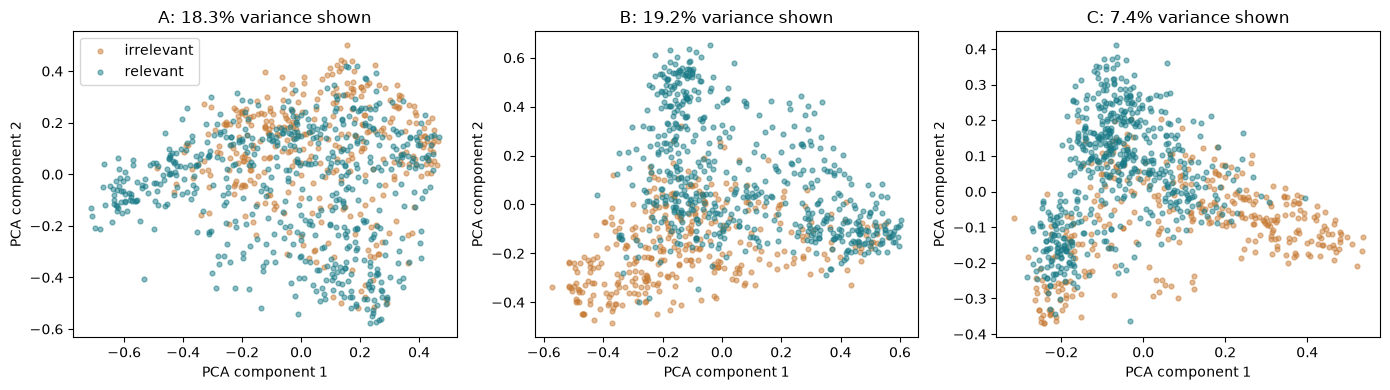

In [4]:
evidence = pd.read_csv(st.SRC / 'analysis_outputs' / 'embedding_evidence_summary.csv')
display(evidence[['space', 'dimensions', 'binary_silhouette', 'intent_silhouette', 'variance_first_2', 'components_for_95pct', 'macro_label_agreement']])
st.pca_plot(train, embeddings)
plt.show()


B showed the strongest descriptive label separation among these spaces, but all three showed overlap. C has more dimensions; that alone does not make it the best input for a classifier.

We also look at exact duplicates and queries whose neighbours often have a different label. These are useful candidates for investigation, not proof of incorrect labels. Without query text, we cannot establish why a point is unusual. Exact duplicates in any of the three spaces were connected into groups and kept together during validation.

In [5]:
duplicates = pd.read_csv(st.SRC / 'analysis_outputs' / 'exact_duplicates.csv')
display(duplicates)
local_overlap = pd.read_csv(st.SRC / 'analysis_outputs' / 'training_neighborhood_diagnostics.csv')
display(local_overlap.sort_values('label_agreement_k15').head(10))


,space,row,query_id,intent,label,group_size
0,A,120,q_00177,Other,relevant,2
1,A,584,q_00132,Other,relevant,2
2,B,120,q_00177,Other,relevant,2
3,B,584,q_00132,Other,relevant,2


,query_id,intent,label,space,nearest_distance,label_agreement_k15
1141,q_01660,OSS,irrelevant,B,0.190007,0.0
1807,q_01282,Feedback,relevant,C,0.532662,0.0
170,q_01049,Spam,irrelevant,A,0.531608,0.0
231,q_01435,Feedback,relevant,A,0.182425,0.0
1834,q_00059,Other,relevant,C,0.512261,0.0
1273,q_01591,OSS,irrelevant,B,0.465909,0.0
127,q_00472,Medical,relevant,A,0.265797,0.0
920,q_01587,OSS,irrelevant,B,0.135104,0.0
1030,q_00472,Medical,relevant,B,0.316510,0.0
1073,q_01049,Spam,irrelevant,B,0.539980,0.0


## 4. How do we compare models fairly?

We use the same **five outer folds** for all three model families. Each query is held out once, giving one held-out prediction per labeled query. Within each outer training partition, **three inner folds** select the embedding, model settings, probability calibration, and decision thresholds. Exact duplicate groups stay together. Outer labels do not choose those settings.

Candidate settings are ranked by **average precision**, a summary of precision across recall levels. Raw probabilities are compared with sigmoid calibration using inner **Brier score**, where lower is better. Scaling, where used, is fitted only on the relevant training partition.

We compare three decision policies consistently:

- **Default 0.50:** refer when the selected probability is at least 0.50.
- **Balanced macro-F1:** select an inner-development threshold that balances F1 across both labels.
- **Recall-first:** minimize false positives while meeting illustrative inner targets of 98% relevant recall and 99% Medical recall.

Those targets are assumptions for exploration, not clinical guarantees. Final settings are selected again using all labeled data before fitting the model that predicts the blind test. The final model's threshold can differ from the thresholds used in outer evaluation.

The next cell optionally retrains LR, RF, and MLP in that order. With the default setting it reads the completed experiments instead. Training uses the original CPU implementations; the MLP does not use a GPU.

In [6]:
if RETRAIN_ALL:
    st.train_models()
else:
    print('Using included experiment results. No model fitting requested.')

fold_sizes = pd.DataFrame({name: st.table(name, 'outer_predictions.csv').groupby('outer_fold').size() for name in st.MODEL_DIRS})
display(fold_sizes.rename_axis('Outer fold'))


Using included experiment results. No model fitting requested.


,LR,RF,MLP
Outer fold,,,
0,181,181,181
1,181,181,181
2,180,180,180
3,180,180,180
4,181,181,181


## 5. Logistic regression: our simplest model

Logistic regression learns a weighted combination of embedding coordinates and turns it into a probability. It is a useful baseline because it is relatively simple, fast, and less flexible than a forest or neural network.

In this section, we show the final saved settings, the three policies on held-out rows, and the effect of changing the threshold on inner-development data. Precision means **how many referrals were actually relevant**; recall means **how many relevant queries were caught**. Read both alongside the numbers of missed queries and referrals.

The threshold curves are development diagnostics. The policy table is the held-out evaluation. They answer different questions and should not be mixed when claiming performance.

**LR: final settings selected using development data**

,Saved value
outer_fold_choices,"[{'outer_fold': 0, 'outer_train_rows': 722, 'o..."
final_embedding,b
final_C,10.0
final_class_weight,balanced
final_mean_inner_average_precision,0.963138
final_probability_method,sigmoid
final_brier_raw,0.092997
final_brier_sigmoid,0.091922
final_thresholds,"{'default_0_5': 0.5, 'balanced_macro_f1': 0.43..."
recommended_policy,recall_first


,policy,accuracy,precision,recall,macro_f1,fn,fp,medical_fn,referrals
0,default_0_5,87.26%,88.10%,91.74%,86.35%,46,69,14,nan
1,balanced_macro_f1,86.60%,88.25%,90.31%,85.72%,54,67,18,nan
2,recall_first,83.94%,80.29%,98.03%,81.40%,11,134,1,nan


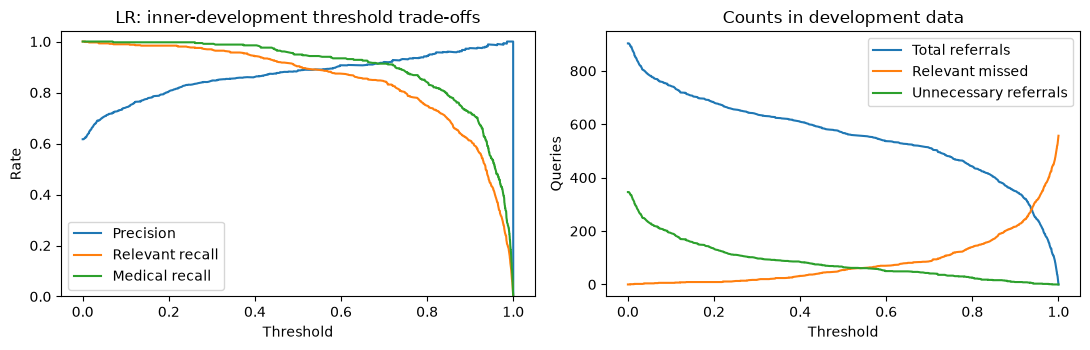

ValueError: cannot convert float NaN to integer

In [7]:
st.model_section('LR')


## 6. Random forest: a more flexible model

A random forest combines many decision trees. Each tree learns rules using selected embedding coordinates, and the forest combines their predictions. Depth, minimum leaf size, feature sampling, and class weights control how flexible the model becomes.

We use the same evaluation and threshold procedure as LR. Compare how many relevant and Medical queries are missed at each policy, and how many referrals the team would receive. Extra flexibility is worthwhile only when those trade-offs improve.

**RF: final settings selected using development data**

,Saved value
outer_fold_choices,"[{'outer_fold': 0, 'outer_train_rows': 722, 'o..."
final_embedding,b
final_config_id,rf_09
final_forest_params,"{'n_estimators': 200, 'max_depth': 8, 'min_sam..."
final_mean_inner_average_precision,0.968325
final_probability_method,sigmoid
final_brier_raw,0.105762
final_brier_sigmoid,0.0893
final_thresholds,"{'default_0_5': 0.5, 'balanced_macro_f1': 0.59..."
recommended_policy,recall_first


,policy,accuracy,precision,recall,macro_f1,fn,fp,medical_fn,referrals
3,default_0_5,87.04%,87.93%,91.56%,86.11%,47,70,7,580.000000
4,balanced_macro_f1,86.82%,88.83%,89.95%,86.01%,56,63,10,564.000000
5,recall_first,84.83%,81.53%,97.49%,82.65%,14,123,0,666.000000


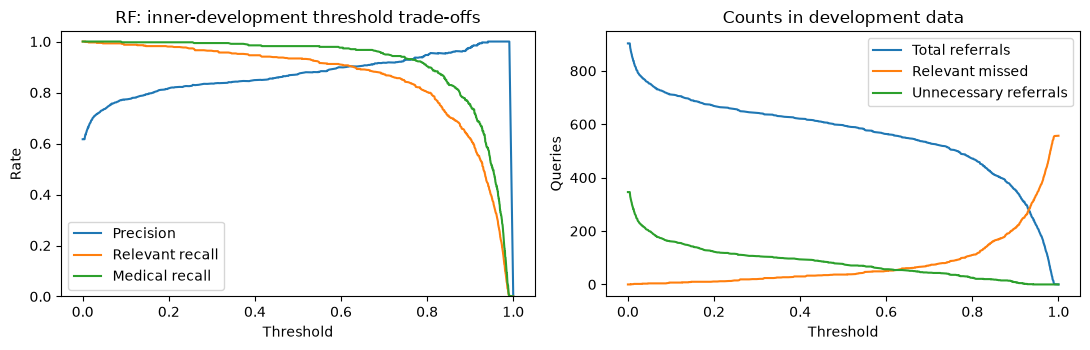

Compared with default 0.50, recall-first changes referrals by **+86**, relevant misses by **-33**, and Medical misses by **-7**, across the 903 held-out development predictions.

In [8]:
st.model_section('RF')


## 7. Neural network: a small MLP

An MLP passes the embedding through one or two hidden layers. These layers can learn nonlinear combinations of coordinates. With only 903 labeled rows, a large network can memorize examples, so we use small architectures and regularization.

The declared search contains 54 candidates per search: three embedding spaces, three architectures, three regularization strengths, and two learning rates. The iteration limit is 300. Internal random early stopping is disabled to avoid introducing an ungrouped validation split. Recorded convergence diagnostics show whether a fit reached that limit.

This is the newer MLP experiment. The earlier exploratory `version3` attempt is not substituted for these results. We apply exactly the same policy comparison as for LR and RF.

**MLP: final settings selected using development data**

,Saved value
final_embedding,c
final_config_id,mlp_c_00
final_hidden_layer_sizes,[32]
final_alpha,0.01
final_learning_rate_init,0.0005
final_mean_inner_average_precision,0.967665
final_probability_method,raw
final_brier_raw,0.106059
final_brier_sigmoid,0.10692
final_thresholds,"{'default_0_5': 0.5, 'balanced_macro_f1': 0.71..."


,policy,accuracy,precision,recall,macro_f1,fn,fp,medical_fn,referrals
6,default_0_5,87.26%,88.91%,90.66%,86.45%,52,63,11,568.000000
7,balanced_macro_f1,87.38%,89.48%,90.13%,86.62%,55,59,14,561.000000
8,recall_first,86.05%,83.20%,96.95%,84.28%,17,109,1,649.000000


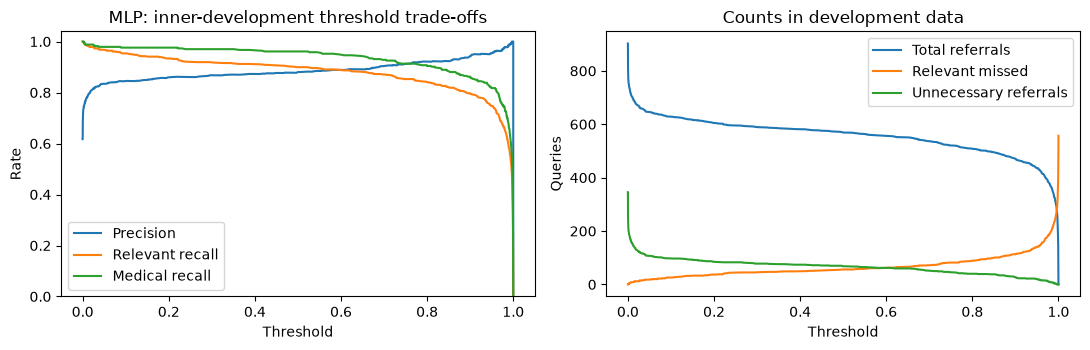

Compared with default 0.50, recall-first changes referrals by **+81**, relevant misses by **-35**, and Medical misses by **-10**, across the 903 held-out development predictions.

,selection_scope,config_id,inner_n_iter_0,inner_loss_0,inner_hit_max_iter_0,inner_convergence_warning_0,inner_n_iter_1,inner_loss_1,inner_hit_max_iter_1,inner_convergence_warning_1,inner_n_iter_2,inner_loss_2,inner_hit_max_iter_2,inner_convergence_warning_2
0,outer_fold_0,mlp_a_00,173,0.011333,False,False,194,0.010152,False,False,181,0.011488,False,False
1,outer_fold_0,mlp_a_01,119,0.009629,False,False,132,0.008862,False,False,128,0.009509,False,False
2,outer_fold_0,mlp_a_02,247,0.118122,False,False,225,0.111978,False,False,255,0.118868,False,False
3,outer_fold_0,mlp_a_03,136,0.120513,False,False,128,0.113942,False,False,135,0.120842,False,False
4,outer_fold_0,mlp_a_04,210,0.668040,False,False,215,0.666861,False,False,206,0.666976,False,False
5,outer_fold_0,mlp_a_05,134,0.666785,False,False,137,0.665917,False,False,128,0.665973,False,False
6,outer_fold_0,mlp_a_06,158,0.014112,False,False,184,0.012656,False,False,170,0.014038,False,False
7,outer_fold_0,mlp_a_07,123,0.011781,False,False,104,0.012299,False,False,127,0.011955,False,False
8,outer_fold_0,mlp_a_08,207,0.119039,False,False,196,0.111819,False,False,188,0.119960,False,False
9,outer_fold_0,mlp_a_09,106,0.128719,False,False,106,0.116052,False,False,108,0.127544,False,False


In [9]:
st.model_section('MLP')
mlp_candidates = st.table('MLP', 'candidate_results.csv')
diagnostic_columns = [c for c in mlp_candidates.columns if any(term in c for term in ['n_iter', 'loss', 'convergence', 'hit_max'])]
display(mlp_candidates[['selection_scope', 'config_id'] + diagnostic_columns].head(12))


## 8. Ranking quality and useful confidence

**ROC AUC** measures how well relevant queries rank above irrelevant ones. **Average precision** summarizes the precision–recall curve and is sensitive to the label distribution. Neither chooses an operating threshold for the nursing team.

**Calibration** asks whether scores behave like probabilities: among queries assigned about 0.8, roughly 80% should be relevant. Brier score evaluates probability error; lower is better. Small calibration bins can be noisy.

These curves pool held-out scores from different fitted outer models and should be treated as descriptive estimates. The LLM baseline supplies labels only, so it has no ROC or precision–recall curve here.

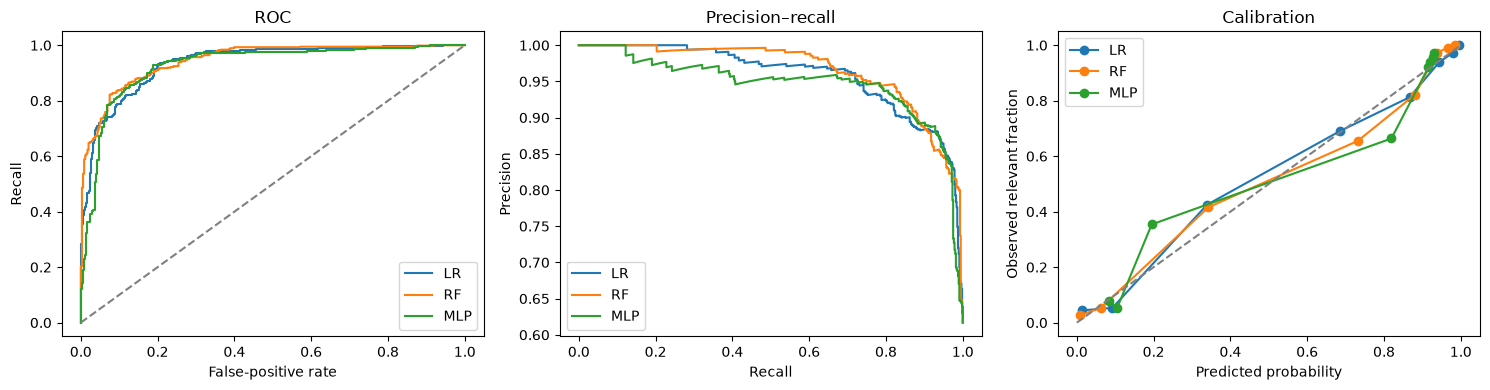

,model,ROC AUC,Average precision,Brier score
0,LR,0.9366,0.9584,0.0945
1,RF,0.9454,0.9654,0.0923
2,MLP,0.9273,0.9464,0.1011


In [10]:
display(st.ranking_and_calibration().round(4))


## 9. All models in one comparison

This table puts the three local model families and the supplied LLM baseline together. Accuracy is useful, but a high accuracy can hide important missed queries. Medical misses, total relevant misses, false positives, and referral count make the routing consequences easier to judge.

The original Version 1 single-holdout result used only 181 evaluation rows, so we use its later nested Part 2 experiment here. Comparing model families on these outer results introduces another selection decision; a fresh prospective labeled evaluation is still needed before treating the chosen family as independently validated.

In [11]:
results = st.comparison()
columns = ['model', 'policy', 'accuracy', 'macro_f1', 'precision', 'recall', 'medical_fn', 'fn', 'fp', 'referrals', 'roc_auc', 'average_precision']
display(results[columns].style.format({c: '{:.3f}' for c in ['accuracy', 'macro_f1', 'precision', 'recall', 'roc_auc', 'average_precision']}, na_rep='Not available'))

choice = st.best_local(results)
print('Local selection rule: fewest Medical misses, then relevant misses, then false positives, then highest macro-F1.')
print('Selected local candidate:', choice.model, '/', choice.policy)
print('This rule reflects an assumed priority for avoiding misses; it is not a clinical guarantee.')


,model,policy,accuracy,macro_f1,precision,recall,medical_fn,fn,fp,referrals,roc_auc,average_precision
0,LR,default_0_5,0.873,0.863,0.881,0.917,14,46,69,Not available,0.937,0.958
1,LR,balanced_macro_f1,0.866,0.857,0.882,0.903,18,54,67,Not available,0.937,0.958
2,LR,recall_first,0.839,0.814,0.803,0.980,1,11,134,Not available,0.937,0.958
3,RF,default_0_5,0.870,0.861,0.879,0.916,7,47,70,580.000000,0.945,0.965
4,RF,balanced_macro_f1,0.868,0.860,0.888,0.899,10,56,63,564.000000,0.945,0.965
5,RF,recall_first,0.848,0.826,0.815,0.975,0,14,123,666.000000,0.945,0.965
6,MLP,default_0_5,0.873,0.864,0.889,0.907,11,52,63,568.000000,0.927,0.946
7,MLP,balanced_macro_f1,0.874,0.866,0.895,0.901,14,55,59,561.000000,0.927,0.946
8,MLP,recall_first,0.860,0.843,0.832,0.969,1,17,109,649.000000,0.927,0.946
9,LLM,frozen_label,0.979,0.978,0.979,0.987,0,7,12,562.000000,Not available,Not available


Local selection rule: fewest Medical misses, then relevant misses, then false positives, then highest macro-F1.
Selected local candidate: RF / recall_first
This rule reflects an assumed priority for avoiding misses; it is not a clinical guarantee.


## 10. Where does the recommended local classifier make mistakes?

A **false positive (Type I error)** refers an irrelevant query, increasing nurse workload. A **false negative (Type II error)** misses a relevant query, so the intended workflow may not see it. The consequences differ, which is why we do not optimize accuracy alone.

Here we break down the chosen local policy by the supplied source intents. A blank recall for a category with no relevant examples is intentional: relevant recall is not defined for that category. Small groups deserve caution because a few errors can change their rates substantially.

,rows,relevant,missed_relevant,unnecessary_referrals,referrals,relevant_recall
intent,,,,,,
Acknowledgment,208,0,0,48,48,NaN
Automated message,22,0,0,5,5,NaN
Date,22,22,0,0,22,1.000000
Delivery confirmation,46,46,2,0,44,0.956522
Feedback,34,34,6,0,28,0.823529
Greeting,46,0,0,13,13,NaN
Language change,70,70,0,0,70,1.000000
Medical,334,334,0,0,334,1.000000
OSS,57,0,0,44,44,NaN


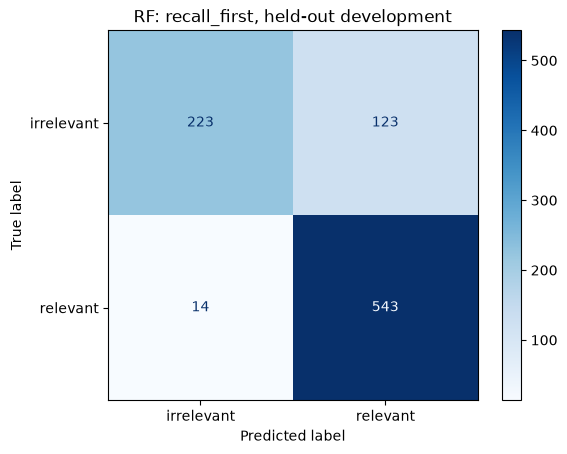

In [12]:
display(st.intent_results(choice))
outer = st.table(choice.model, 'outer_predictions.csv')
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(outer.truth, outer['label_' + choice.policy], labels=[0, 1], display_labels=['irrelevant', 'relevant'], cmap='Blues')
plt.title(f'{choice.model}: {choice.policy}, held-out development')
plt.show()


## 11. Cost and production recommendation

At one million queries per month, the supplied LLM pricing gives **$500 for input tokens plus $40 for output tokens = $540 per month**. Local classification-head compute is assumed negligible by the assignment. This does not make the entire local pipeline free: embeddings, infrastructure, and human review are additional costs.

For a hybrid sending a fraction `r` of queries to the LLM, the corresponding LLM token cost is `$540 × r`. No hybrid quality has been measured here. Encoder costs and end-to-end latency are unknown because the embeddings are precomputed. A/B require local encoder capacity; C requires hosted encoder pricing and latency assumptions. Fair production comparisons must include those costs and the cost of nurse referrals.

The supplied LLM is the strongest measured overall baseline in the existing experiments. The recommendation is to evaluate it prospectively with human fallback before deployment, subject to privacy, latency, availability, and operational constraints. The selected local classifier is a candidate when those constraints favor local routing. Its CSV below satisfies the local-classifier handoff; this is distinct from the broader production design.

For uncertain or out-of-distribution cases, use human review or an explicitly evaluated escalation route. Do not automatically reject a query because a probability looks low. Monitor delayed-label quality, Medical misses, intent-level errors, referral volume, drift, encoder versions, and latency. Revalidate thresholds after distribution or encoder changes. An LLM label alone does not supply a calibrated confidence score.

In [13]:
monthly_queries = 1_000_000
input_cost = monthly_queries * 250 / 1_000_000 * 2
output_cost = monthly_queries * 5 / 1_000_000 * 8
print(f'Full LLM token cost: ${input_cost:,.0f} input + ${output_cost:,.0f} output = ${input_cost + output_cost:,.0f}/month')
display(pd.DataFrame({'Fraction sent to LLM': [0, .1, .25, .5, 1], 'Monthly LLM token cost (USD)': [(input_cost + output_cost) * r for r in [0, .1, .25, .5, 1]]}))
print('These costs are scenario assumptions, not measured production bills or latency benchmarks.')


Full LLM token cost: $500 input + $40 output = $540/month


,Fraction sent to LLM,Monthly LLM token cost (USD)
0,0.00,0.0
1,0.10,54.0
2,0.25,135.0
3,0.50,270.0
4,1.00,540.0


These costs are scenario assumptions, not measured production bills or latency benchmarks.


## 12. Export the recommended local classifier's test predictions

The final output contains a query ID, probability, predicted routing label, model family, policy, and threshold. We use the selected model's saved final-fit test probabilities and its final-development threshold. We do not use blind-test labels for selection because none were supplied.

The CSV and its metadata are written under **`src/results/`** when you run this cell. The selected model artifact and its training implementation are already under `src/experiments/`. The copied recommended predictions in the earlier MLP folder are not used by this combined notebook.

This notebook combines the earlier human-readable data and model sections into one submission entry point. Model work and saved measurements came from the existing experiments; the combined notebook itself has not been executed or tested during assembly. AI assistance was used for implementation, explanations, and organization.

In [14]:
predictions, prediction_path = st.export_predictions(choice)
display(predictions.head())
print('Test rows:', len(predictions))
print('Prediction file:', prediction_path)
print('Metadata:', prediction_path.with_name('recommendation.json'))
print('No test accuracy is reported: verified test labels are not supplied.')


,query_id,p_relevant,predicted_label,model,policy,threshold
0,q_00271,0.964975,relevant,RF,recall_first,0.207687
1,q_01038,0.275985,relevant,RF,recall_first,0.207687
2,q_00418,0.891009,relevant,RF,recall_first,0.207687
3,q_00212,0.233629,relevant,RF,recall_first,0.207687
4,q_01124,0.875468,relevant,RF,recall_first,0.207687


Test rows: 904
Prediction file: C:\Aditya\Prep\noora\submission\src\results\recommended_test_predictions.csv
Metadata: C:\Aditya\Prep\noora\submission\src\results\recommendation.json
No test accuracy is reported: verified test labels are not supplied.
